# Optimisation de portefeuille — Markowitz (V2, framework expérimental)

**Univers** : S&P 500 (configurable) — **Fréquence** : configurable — **Estimateurs de covariance multiples**

---

## Rajouts à la V1

Refonte en un **framework expérimental modulaire**


1.  **Sélection d'univers configurable** (tout / aléatoire / Top N / stratifié par secteur): Échantillons reproductibles, contrôle du biais, diversification sectorielle. 
2.  **Rendements simples (défaut) ou log**: Possibilité de choisir l'un ou l'autre
3.  **Fréquences daily/weekly/monthly/yearly** 
4.  **Estimateurs de covariance interchangeables** : empirique, rolling, **EWMA (RiskMetrics)**, Ledoit-Wolf: La covariance empirique réagissant lentement aux chocs (effet « fantôme »), la mesure de risque dynamique et matrices mieux conditionnées.
5. **Fonctions objectif configurables** : max Sharpe, min variance, max rendement, utilité. Comparaison systématique des profils de portefeuille.
6. **Méthodes d'optimisation extensibles** : Lagrangien analytique, QP CVXPY, SLSQP, **Differential Evolution**: Benchmarks méthodologiques, méthodes sans gradient. 
7. **Fonction centrale `run_experiment(config)`**: Tout est piloté par un objet `ExperimentConfig` et les expériences reproductibles et benchmarkables.
8. **Taux sans risque paramétrable** (annuel, converti proprement):  La V1 codait un proxy hebdo arbitraire. Sharpe correct quelle que soit la fréquence. 
9. **Analyse & visualisations automatiques** + section de comparaison des estimateurs: Lecture « mini-rapport ». 




> 
> **Rappel méthodologique clé (issu de l'analyse RiskMetrics)** : les estimateurs avancés améliorent **Σ**
> (le risque), **pas μ** (le rendement espéré). Or en Markowitz, c'est l'erreur sur μ qui domine l'instabilité
> du portefeuille tangent (Michaud, « error-maximizing machine »). On attend donc le gain le plus net sur le
> **portefeuille à variance minimale (MVP)**, qui ne dépend que de Σ.

# Définitions des termes utilisés dans ce notebook

---

## Prix et rendements

### Prix ($P_t$)

**Définition**  
Valeur de marché d'un actif financier à l'instant $t$.

**Utilité**  
En optimisation de portefeuille, on utilise généralement les prix de clôture ajustés, qui intègrent les dividendes et les opérations sur titres (splits).

---

### Rendement simple

**Définition**  
Variation relative du prix entre deux périodes consécutives.

**Expression**

$$
r_t^{\text{simple}}
=
\frac{P_t-P_{t-1}}{P_{t-1}}
$$

**Utilité**

- Exact pour l'agrégation de portefeuille :
  
  $$
  \mu_p = w^\top \mu
  $$

- Recommandé pour l'optimisation de portefeuille.

---

### Rendement logarithmique (log-rendement)

**Définition**  
Logarithme naturel du rapport entre deux prix successifs.

**Expression**

$$
r_t^{\log}
=
\ln\left(\frac{P_t}{P_{t-1}}\right)
$$

**Utilité**

- Additif dans le temps.
- Facilite souvent les hypothèses de normalité.
- En contrepartie,

  $$
  \mu_p = w^\top \mu
  $$

  n'est qu'une approximation.

---

## Statistiques fondamentales

### Rendement espéré ($\mu$)

**Définition**  
Vecteur des rendements moyens attendus des actifs.

**Estimateur empirique**

$$
\hat{\mu}_i
=
\frac{1}{T}
\sum_{t=1}^{T} r_{i,t}
$$

**Utilité**

- Détermine le rendement attendu du portefeuille.
- Paramètre le plus sensible aux erreurs d'estimation.
- Une mauvaise estimation de $\mu$ peut conduire à des portefeuilles très instables.

---

### Matrice de covariance ($\Sigma$)

**Définition**  
Matrice $N \times N$ décrivant :

- les volatilités individuelles (diagonale) ;
- les co-mouvements entre actifs (hors diagonale).

**Expression**

$$
\sigma_p^2
=
w^\top \Sigma w
=
\sum_i w_i^2 \sigma_i^2
+
\sum_{i \neq j}
w_i w_j \sigma_{ij}
$$



**Utilité**

- Élément central du modèle de Markowitz.
- La diversification agit principalement via les termes de covariance hors diagonale.

---

## Estimateurs de covariance

### Covariance empirique

**Définition**  
Estimateur donnant le même poids à toutes les observations historiques.

**Expression**

$$
\hat{\Sigma}
=
\frac{1}{T-1}
\sum_{t=1}^{T}
(r_t-\hat{\mu})
(r_t-\hat{\mu})^\top
$$

$$\hat\Sigma_{ij} = \frac{1}{T-1}\sum_{t=1}^T (r_{i,t} - \hat\mu_i)(r_{j,t} - \hat\mu_j)$$

**Utilité**

- Simple à calculer.
- Non biaisé.
- Réagit lentement aux changements de régime.
- Peut devenir mal conditionné lorsque

  $$
  N \gg T.
  $$

---

### Covariance rolling (fenêtre glissante)

**Définition**  
Covariance empirique calculée uniquement sur les $W$ dernières observations.

**Utilité**

- Plus réactive aux régimes récents.
- Sensible à l'effet de bord (« effet fantôme ») lorsque des observations sortent brutalement de la fenêtre.

---

### EWMA (Exponentially Weighted Moving Average)

**Définition**  
Estimateur où les observations passées reçoivent un poids exponentiellement décroissant.

**Poids**

$$
w_t
=
(1-\lambda)\lambda^{T-1-t}
$$

**Covariance**

$$
\hat{\Sigma}
=
X_w^\top X_w
$$

où $X_w$ est la matrice des rendements pondérés par $\sqrt{w_t}$.

**Utilité**

- Très réactif aux chocs récents.
- Produit une matrice semi-définie positive (PSD).
- Paramètres RiskMetrics :

  - $\lambda = 0.94$ (quotidien)
  - $\lambda = 0.97$ (mensuel)

- Demi-vie effective :

  $$
  \frac{\ln 2}{\ln(1/\lambda)}
  \approx 74
  \text{ jours}
  \quad (\lambda=0.94)
  $$

---

### Ledoit-Wolf (Shrinkage)

**Définition**  
Technique de régularisation qui rapproche la covariance empirique d'une matrice cible plus stable.

**Utilité**

- Excellent conditionnement.
- Très robuste lorsque

  $$
  N \gg T.
  $$

- Introduit volontairement un biais afin de réduire la variance de l'estimateur.

## 1. Imports, configuration globale et objet d'expérience

On centralise **tous** les paramètres d'une expérience dans une `dataclass` `ExperimentConfig`.

In [1]:
from __future__ import annotations
import warnings
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Dépendances optionnelles : on les importe paresseusement pour que le notebook
# reste lisible même si l'une manque. cvxpy et yfinance étaient déjà utilisés en V1.
try:
    import yfinance as yf
except ImportError:
    yf = None
    print("[INFO] yfinance non installé — `pip install yfinance` pour télécharger les prix.")
try:
    import cvxpy as cp
except ImportError:
    cp = None
    print("[INFO] cvxpy non installé — `pip install cvxpy` pour l'optimiseur QP.")

In [2]:
@dataclass
class ExperimentConfig:
    """Décrit UNE expérience d'optimisation de bout en bout.

    Tous les leviers du framework sont ici : changer un champ suffit à relancer
    une variante. C'est l'objet passé à `run_experiment()`.
    """
    # --- Univers ---
    universe: "UniverseSelector" = None          # ex. TopN(50), RandomN(30), StratifiedBySector(60)
    start_date: str = "2022-01-01"
    end_date:   str = "2025-12-31"

    # --- Données ---
    frequency:    str = "daily"                   # daily | weekly | monthly | yearly
    return_mode:  str = "simple"                  # simple | log

    # --- Estimation ---
    cov_estimator:  "CovarianceEstimator" = None  # défaut : EmpiricalCovariance()
    mean_estimator: "MeanEstimator"       = None  # défaut : SampleMean()
    risk_free_annual: float = 0.04                # taux sans risque ANNUEL (ex. T-bill ~4%)

    # --- Optimisation ---
    objective:     str = "max_sharpe"             # max_sharpe | min_variance | max_return | max_utility
    optimizer:     "Optimizer" = None             # défaut : CVXPYOptimizer()
    long_only:     bool  = True
    w_max:         float = 1.0                     # plafond par actif (1.0 = pas de plafond)
    risk_aversion: float = 3.0                     # pour l'objectif "max_utility"

    def resolved(self) -> "ExperimentConfig":
        """Remplit les valeurs par défaut qui dépendent de classes définies plus bas."""
        if self.universe       is None: self.universe       = TopN(50)
        if self.cov_estimator  is None: self.cov_estimator  = EmpiricalCovariance()
        if self.mean_estimator is None: self.mean_estimator = SampleMean()
        if self.optimizer      is None: self.optimizer      = CVXPYOptimizer()
        return self

## 2. Fréquences et annualisation 

Toutes les métriques doivent être **cohérentes avec la fréquence**. On travaille en rendements *par période*
puis on annualise à la toute fin pour l'interprétation. Sous l'hypothèse de rendements i.i.d. :

$$\mu_{\text{annuel}} = k \cdot \mu_{\text{période}}, \qquad \Sigma_{\text{annuel}} = k \cdot \Sigma_{\text{période}}, \qquad \sigma_{\text{annuel}} = \sqrt{k}\,\sigma_{\text{période}}$$

où $k$ est le nombre de périodes par an. Le facteur $\sqrt{k}$ sur la volatilité vient du fait que la variance
d'une somme de $k$ variables i.i.d. est $k$ fois la variance d'une seule (la « racine du temps »).

In [3]:
PERIODS_PER_YEAR = {"daily": 252, "weekly": 52, "monthly": 12, "yearly": 1}
RESAMPLE_RULE    = {"daily": None, "weekly": "W-FRI", "monthly": "ME", "yearly": "YE"}

def resample_prices(prices: pd.DataFrame, frequency: str) -> pd.DataFrame:
    """Ré-échantillonne les prix en prenant le DERNIER prix de chaque période."""
    rule = RESAMPLE_RULE[frequency]
    return prices if rule is None else prices.resample(rule).last()

def annualize(mu_period: np.ndarray, Sigma_period: np.ndarray, frequency: str):
    """Passe des rendements/covariance par période à l'annuel (hyp. i.i.d.)."""
    k = PERIODS_PER_YEAR[frequency]
    return mu_period * k, Sigma_period * k

## 3. Données et sélection de l'univers dans le S&P_500

### Récupération des composants du S&P 500 (avec secteurs)


In [4]:
import requests
from io import StringIO

# Fallback minimal si Wikipédia est inaccessible (réseau coupé, etc.)
_FALLBACK = {
    "AAPL":"Information Technology","MSFT":"Information Technology","NVDA":"Information Technology",
    "AMZN":"Consumer Discretionary","GOOGL":"Communication Services","META":"Communication Services",
    "BRK-B":"Financials","JPM":"Financials","V":"Financials","JNJ":"Health Care",
    "UNH":"Health Care","XOM":"Energy","PG":"Consumer Staples","HD":"Consumer Discretionary",
    "MA":"Financials","LLY":"Health Care","AVGO":"Information Technology","CVX":"Energy",
}

def get_sp500_constituents() -> pd.DataFrame:
    """Retourne un DataFrame indexé par ticker avec une colonne 'sector'."""
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        response = requests.get(url, headers=headers, timeout=15)   
        df = pd.read_html(StringIO(response.text))[0]
        df["Symbol"] = df["Symbol"].str.replace(".", "-", regex=False)  # BRK.B -> BRK-B (format Yahoo)
        out = df.set_index("Symbol")[["GICS Sector"]].rename(columns={"GICS Sector": "sector"})
        print(f"[OK] {len(out)} composants récupérés depuis Wikipédia.")
        return out
    except Exception as e:
        print(f"[FALLBACK] Wikipédia inaccessible ({e}). Liste codée en dur.")
        return pd.DataFrame.from_dict(_FALLBACK, orient="index", columns=["sector"])

###  Stratégies de sélection d'univers (patron *Strategy*)

Chaque stratégie partage la même interface `select(...)`. Ajouter une nouvelle méthode de sélection
= écrire une classe. Les quatre demandées sont fournies ; l'architecture en accepte d'autres.

In [5]:
class UniverseSelector(ABC):
    """Sélectionne une liste de tickers parmi les composants disponibles."""
    name = "base"
    @abstractmethod
    def select(self, constituents: pd.DataFrame) -> list[str]: ...

class AllUniverse(UniverseSelector):
    """Tout l'univers (défaut « métier » demandé). Attention : N≈500."""
    name = "all"
    def select(self, constituents): return constituents.index.tolist()

class TopN(UniverseSelector):
    """Les N premiers (Wikipédia ~ ordonné par capitalisation). Heuristique simple."""
    name = "top_n"
    def __init__(self, n=50): self.n = n
    def select(self, constituents): return constituents.index[: self.n].tolist()

class RandomN(UniverseSelector):
    """N actifs tirés aléatoirement (reproductible via seed)."""
    name = "random_n"
    def __init__(self, n=30, seed=RANDOM_SEED): self.n, self.seed = n, seed
    def select(self, constituents):
        rng = np.random.default_rng(self.seed)
        idx = rng.choice(len(constituents), size=min(self.n, len(constituents)), replace=False)
        return constituents.index[idx].tolist()

class StratifiedBySector(UniverseSelector):
    """Échantillonnage stratifié : ~même nombre d'actifs par secteur GICS.
    Améliore la diversification structurelle de l'univers (≠ concentration tech)."""
    name = "stratified"
    def __init__(self, n_total=60, seed=RANDOM_SEED): self.n_total, self.seed = n_total, seed
    def select(self, constituents):
        rng = np.random.default_rng(self.seed)
        sectors = constituents["sector"].dropna().unique()
        per = max(1, self.n_total // len(sectors))
        picks = []
        for s in sectors:
            members = constituents.index[constituents["sector"] == s].tolist()
            k = min(per, len(members))
            picks += list(rng.choice(members, size=k, replace=False))
        return picks[: self.n_total]

### Téléchargement et nettoyage des prix

In [6]:
def download_prices(tickers: list[str], start: str, end: str) -> pd.DataFrame:
    """Télécharge les prix de clôture AJUSTÉS (dividendes/splits) via yfinance."""
    if yf is None:
        raise ImportError("yfinance requis : pip install yfinance")
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True,
                      progress=False, threads=True)
    prices = raw["Close"] if isinstance(raw.columns, pd.MultiIndex) else raw
    return prices.sort_index()

def clean_prices(prices: pd.DataFrame, max_missing: float = 0.05) -> pd.DataFrame:
    """Élimine les tickers trop incomplets, forward-fill les trous résiduels."""
    keep = prices.columns[prices.isna().mean() <= max_missing]
    prices = prices[keep].ffill().dropna(how="any")
    return prices

## 4. Rendements 

$$r_t^{\text{simple}} = \frac{P_t - P_{t-1}}{P_{t-1}}, \qquad r_t^{\log} = \ln\!\Big(\frac{P_t}{P_{t-1}}\Big)$$

- **Simples** (défaut) : *exacts* pour l'agrégation de portefeuille, $\mu_p = w^\top\mu$ est rigoureusement vrai.
- **Log** : additifs dans le temps et mieux gaussianisés, mais $\mu_p = w^\top\mu$ n'est qu'approché.

Pour de l'optimisation de portefeuille, les rendements **simples** sont théoriquement préférables — d'où le défaut.

In [7]:
def compute_returns(prices: pd.DataFrame, mode: str = "simple") -> pd.DataFrame:
    """Calcule les rendements période-sur-période selon le mode choisi."""
    if mode == "simple":
        return prices.pct_change().dropna(how="any")
    if mode == "log":
        return np.log(prices / prices.shift(1)).dropna(how="any")
    raise ValueError(f"mode inconnu : {mode!r} (attendu 'simple' ou 'log')")

## 5. Estimation de μ et de Σ — dépendances entre actifs 

### Pourquoi la matrice de covariance est le cœur du risque

Le risque d'un portefeuille **n'est pas** la moyenne des risques individuels : il dépend des **dépendances**
entre actifs via les termes hors-diagonale de Σ.

$$\sigma_p^2 = w^\top \Sigma w = \underbrace{\sum_i w_i^2 \sigma_i^2}_{\text{risques propres}} + \underbrace{\sum_{i\neq j} w_i w_j \,\sigma_{ij}}_{\text{co-mouvements}}$$

- **Impact diversification** : des actifs peu (ou négativement) corrélés réduisent $\sigma_p$ → c'est *tout* le
  principe de Markowitz. Sur le S&P 500, les corrélations sont majoritairement **positives** (facteur marché
  commun), ce qui limite la diversification atteignable.
- **Impact risque** : sous-estimer les corrélations (ex. les figer alors qu'elles montent en crise) fait
  **sous-estimer** le risque réel du portefeuille.

### Quatre estimateurs interchangeables 

| Estimateur | Idée | Force | Limite |
|---|---|---|---|
| **Empirique** | Tous les jours pèsent pareil | Simple, non biaisé | Lent face aux chocs ; mal conditionné si N≫T |
| **Rolling** | Fenêtre glissante fixe | Capte les régimes récents | Effet « fantôme » quand une obs. sort |
| **EWMA**  | Poids décroissant exponentiellement, $\lambda$=0.94 (daily) | Réactif, PSD garanti, lisse | Ne corrige pas le rang ; ~74 j effectifs |
| **Ledoit-Wolf** | *Shrinkage* vers une cible structurée | Excellent conditionnement (N≫T) | Hors RiskMetrics ; biais volontaire |

In [8]:
class MeanEstimator(ABC):
    name = "base"
    @abstractmethod
    def estimate(self, returns: pd.DataFrame) -> np.ndarray: ...

class SampleMean(MeanEstimator):
    """μ = moyenne empirique. (Extensible : shrinkage de moyenne, vues Black-Litterman…)"""
    name = "moyenne_empirique"
    def estimate(self, returns): return returns.mean().values


class CovarianceEstimator(ABC):
    """Interface commune : rendements (T×N) -> matrice de covariance (N×N) PAR PÉRIODE."""
    name = "base"
    @abstractmethod
    def estimate(self, returns: pd.DataFrame) -> pd.DataFrame: ...

class EmpiricalCovariance(CovarianceEstimator):
    name = "empirique"
    def estimate(self, returns): return returns.cov()

class RollingCovariance(CovarianceEstimator):
    """Covariance équipondérée sur les `window` dernières observations."""
    name = "rolling"
    def __init__(self, window=60): self.window = window
    def estimate(self, returns): return returns.iloc[-self.window:].cov()

class EWMACovariance(CovarianceEstimator):
    """Covariance EWMA (RiskMetrics). lam=0.94 (daily), 0.97 (monthly).
    Factorisation Σ = (X√w)ᵀ(X√w) => SYMÉTRIQUE et SEMI-DÉFINIE POSITIVE par construction.
    Un seul λ pour toute la matrice => PSD garantie (cf. RiskMetrics, Éq. 5.29)."""
    name = "ewma"
    def __init__(self, lam=0.94, demean=False): self.lam, self.demean = lam, demean
    def estimate(self, returns):
        X = returns.values.astype(float)
        if self.demean: X = X - X.mean(axis=0, keepdims=True)
        T = X.shape[0]
        w = (1 - self.lam) * self.lam ** np.arange(T - 1, -1, -1)
        w /= w.sum()
        Xw = X * np.sqrt(w)[:, None]
        return pd.DataFrame(Xw.T @ Xw, index=returns.columns, columns=returns.columns)

class LedoitWolfCovariance(CovarianceEstimator):
    """Shrinkage de Ledoit-Wolf (hors RiskMetrics — complément utile si N≫T)."""
    name = "ledoit-wolf"
    def estimate(self, returns):
        from sklearn.covariance import LedoitWolf
        S = LedoitWolf().fit(returns.values).covariance_
        return pd.DataFrame(S, index=returns.columns, columns=returns.columns)

## 6. Optimisation : objectifs et méthodes configurables 

### Les fonctions objectif

| Objectif | Problème | Dépend de μ ? |
|---|---|---|
| `min_variance` | $\min_w\ w^\top\Sigma w$ | Non → le plus robuste |
| `max_sharpe` | $\max_w\ (w^\top\mu - r_f)/\sqrt{w^\top\Sigma w}$ | Oui (fortement) |
| `max_return` | $\max_w\ w^\top\mu$ | Oui |
| `max_utility` | $\max_w\ w^\top\mu - \tfrac{1}{2}\gamma\,w^\top\Sigma w$ | Oui |

Toutes sous $\sum_i w_i = 1$, plus contraintes optionnelles ($w_i \ge 0$, $w_i \le w_{\max}$).

### Les méthodes 

- **`AnalyticLagrangian`** — solution *exacte en forme fermée* (sans contrainte d'inégalité). Exige Σ inversible.
- **`CVXPYOptimizer`** — programmation convexe ; gère les contraintes ET **passe à l'échelle (N≈500)**. Méthode par défaut.
- **`ScipyOptimizer`** (SLSQP) — généraliste, gère toutes les objectifs et contraintes.
- **`DifferentialEvolutionOptimizer`** — **sans gradient**, métaheuristique globale (lente : petits univers).

In [9]:
from scipy.optimize import minimize, differential_evolution

def portfolio_stats(w, mu, Sigma, rf=0.0):
    """Rendement, volatilité et Sharpe (toutes grandeurs ANNUALISÉES en entrée)."""
    w = np.asarray(w).flatten()
    ret = float(w @ mu)
    vol = float(np.sqrt(max(w @ Sigma @ w, 0.0)))
    sharpe = (ret - rf) / vol if vol > 0 else np.nan
    return ret, vol, sharpe

# -- petites fonctions objectif réutilisées par les optimiseurs numériques (DRY) --
def _neg_sharpe(w, mu, S, rf): 
    v = np.sqrt(w @ S @ w); return -(w @ mu - rf) / v if v > 0 else 1e6
def _variance(w, mu, S, rf):   return w @ S @ w
def _neg_return(w, mu, S, rf): return -(w @ mu)
def _neg_utility(w, mu, S, rf, ra): return -(w @ mu - 0.5 * ra * (w @ S @ w))

In [10]:
class Optimizer(ABC):
    name = "base"
    @abstractmethod
    def solve(self, mu, Sigma, *, objective, rf, long_only, w_max, risk_aversion, mu_target) -> np.ndarray: ...


class AnalyticLagrangian(Optimizer):
    """Forme fermée via multiplicateurs de Lagrange (contraintes d'ÉGALITÉ seulement).
    Constantes A,B,C,D : A=1ᵀΣ⁻¹μ, B=μᵀΣ⁻¹μ, C=1ᵀΣ⁻¹1, D=BC−A²."""
    name = "lagrangien"
    def solve(self, mu, Sigma, *, objective="min_variance", rf=0.0, long_only=False,
              w_max=1.0, risk_aversion=1.0, mu_target=None):
        Si = np.linalg.inv(Sigma); ones = np.ones(len(mu))
        if objective == "min_variance":
            return Si @ ones / (ones @ Si @ ones)
        if objective == "max_sharpe":                       # portefeuille tangent
            ex = mu - rf * ones
            return Si @ ex / (ones @ Si @ ex)
        if objective == "target_return":
            A = ones @ Si @ mu; B = mu @ Si @ mu; C = ones @ Si @ ones; D = B * C - A * A
            l1 = (C * mu_target - A) / D; l2 = (B - A * mu_target) / D
            return Si @ (l1 * mu + l2 * ones)
        raise ValueError(f"Lagrangien ne gère pas l'objectif {objective!r} (pas de forme fermée).")


class CVXPYOptimizer(Optimizer):
    """Optimiseur convexe (QP) — gère toutes les contraintes et passe à l'échelle."""
    name = "cvxpy"
    def solve(self, mu, Sigma, *, objective="max_sharpe", rf=0.0, long_only=True,
              w_max=1.0, risk_aversion=3.0, mu_target=None):
        if cp is None: raise ImportError("cvxpy requis : pip install cvxpy")
        N = len(mu); Sig = cp.psd_wrap(Sigma)
        if objective == "max_sharpe":
            # Reformulation convexe : min yᵀΣy s.c. (μ−rf)ᵀy=1, y≥0 ; puis w = y/Σyᵢ
            y = cp.Variable(N); cons = [(mu - rf) @ y == 1, cp.sum(y) >= 0]
            if long_only: cons += [y >= 0]
            if w_max < 1.0: cons += [y <= w_max * cp.sum(y)]
            cp.Problem(cp.Minimize(cp.quad_form(y, Sig)), cons).solve()
            return y.value / np.sum(y.value)
        w = cp.Variable(N); cons = [cp.sum(w) == 1]
        cons += [w >= 0, w <= w_max] if long_only else [w >= -w_max, w <= w_max]
        if   objective == "min_variance": obj = cp.Minimize(cp.quad_form(w, Sig))
        elif objective == "max_return":   obj = cp.Maximize(mu @ w)
        elif objective == "max_utility":  obj = cp.Maximize(mu @ w - 0.5 * risk_aversion * cp.quad_form(w, Sig))
        elif objective == "target_return":
            cons += [mu @ w == mu_target]; obj = cp.Minimize(cp.quad_form(w, Sig))
        else: raise ValueError(objective)
        cp.Problem(obj, cons).solve()
        return w.value


class ScipyOptimizer(Optimizer):
    """SLSQP — généraliste, toutes objectifs + contraintes (gradient numérique)."""
    name = "slsqp"
    def solve(self, mu, Sigma, *, objective="max_sharpe", rf=0.0, long_only=True,
              w_max=1.0, risk_aversion=3.0, mu_target=None):
        N = len(mu); w0 = np.ones(N) / N
        cons = [{"type": "eq", "fun": lambda w: w.sum() - 1}]
        if objective == "target_return":
            cons.append({"type": "eq", "fun": lambda w: w @ mu - mu_target})
        bounds = [(0, w_max)] * N if long_only else [(-w_max, w_max)] * N
        f = {"max_sharpe":  lambda w: _neg_sharpe(w, mu, Sigma, rf),
             "min_variance":lambda w: _variance(w, mu, Sigma, rf),
             "max_return":  lambda w: _neg_return(w, mu, Sigma, rf),
             "target_return":lambda w: _variance(w, mu, Sigma, rf),
             "max_utility": lambda w: _neg_utility(w, mu, Sigma, rf, risk_aversion)}[objective]
        return minimize(f, w0, method="SLSQP", bounds=bounds, constraints=cons,
                        options={"maxiter": 500, "ftol": 1e-10}).x


class DifferentialEvolutionOptimizer(Optimizer):
    """Métaheuristique SANS GRADIENT (long-only). Lent => réserver aux petits univers (N≲30)."""
    name = "differential_evolution"
    def solve(self, mu, Sigma, *, objective="max_sharpe", rf=0.0, long_only=True,
              w_max=1.0, risk_aversion=3.0, mu_target=None):
        N = len(mu)
        def norm(x):
            x = np.clip(x, 0, None); s = x.sum()
            return x / s if s > 0 else np.ones(N) / N
        def f(x):
            w = norm(x)
            return {"max_sharpe":  _neg_sharpe(w, mu, Sigma, rf),
                    "min_variance":_variance(w, mu, Sigma, rf),
                    "max_return":  _neg_return(w, mu, Sigma, rf),
                    "max_utility": _neg_utility(w, mu, Sigma, rf, risk_aversion)}[objective]
        res = differential_evolution(f, [(0, 1)] * N, seed=RANDOM_SEED,
                                     maxiter=200, tol=1e-8, polish=True)
        return norm(res.x)

## 7. Frontière efficiente

On balaie une grille de rendements cibles et on minimise la variance pour chacun (via l'optimiseur choisi),
ce qui trace la frontière. La frontière est le lieu des portefeuilles optimaux : rendement maximal pour un
risque donné.

In [11]:
def efficient_frontier(mu, Sigma, optimizer, *, rf=0.0, long_only=True, w_max=1.0, n_points=40):
    """Trace la frontière en résolvant `target_return` sur une grille de μ cibles."""
    # MVP comme borne basse ; max rendement atteignable comme borne haute
    w_mvp = optimizer.solve(mu, Sigma, objective="min_variance", rf=rf,
                            long_only=long_only, w_max=w_max)
    mu_lo = float(w_mvp @ mu)
    mu_hi = float(mu.max()) * (0.999 if long_only else 1.5)
    grid = np.linspace(mu_lo, mu_hi, n_points)
    vols, rets = [], []
    for m in grid:
        try:
            w = optimizer.solve(mu, Sigma, objective="target_return", rf=rf,
                                long_only=long_only, w_max=w_max, mu_target=m)
            if w is None: continue
            r, v, _ = portfolio_stats(w, mu, Sigma, rf)
            rets.append(r); vols.append(v)
        except Exception:
            continue
    return np.array(vols), np.array(rets)

## 8. Fonction centrale d'expérience 

`run_experiment(config)` enchaîne **tout** le pipeline et renvoie un objet `ExperimentResult`.
C'est le point d'entrée unique : on construit un `ExperimentConfig`, on le passe ici, on récupère
poids + statistiques + matrices, prêts à analyser ou à benchmarker.

In [12]:
@dataclass
class ExperimentResult:
    config: ExperimentConfig
    tickers: list
    returns: pd.DataFrame
    mu_annual: np.ndarray
    Sigma_annual: pd.DataFrame
    weights: pd.Series
    ret: float
    vol: float
    sharpe: float

    def summary(self) -> pd.Series:
        return pd.Series({
            "objectif": self.config.objective,
            "optimiseur": self.config.optimizer.name,
            "covariance": self.config.cov_estimator.name,
            "fréquence": self.config.frequency,
            "N actifs": len(self.tickers),
            "rendement (%)": self.ret * 100,
            "volatilité (%)": self.vol * 100,
            "Sharpe": self.sharpe,
            "# poids > 1%": int((self.weights > 0.01).sum()),
            "Herfindahl": float((self.weights ** 2).sum()),
        })


def run_experiment(config: ExperimentConfig,
                   constituents: Optional[pd.DataFrame] = None,
                   prices: Optional[pd.DataFrame] = None) -> ExperimentResult:
    """Pipeline complet : univers -> prix -> rendements -> μ,Σ -> annualisation -> optimisation -> stats.

    `constituents` et `prices` peuvent être fournis pour éviter de re-télécharger
    à chaque expérience (utile pour benchmarker plusieurs configs sur les mêmes données).
    """
    cfg = config.resolved()

    # 1) Univers
    if constituents is None:
        constituents = get_sp500_constituents()
    tickers = cfg.universe.select(constituents)

    # 2) Prix (téléchargés si non fournis), puis ré-échantillonnage à la fréquence voulue
    if prices is None:
        prices = clean_prices(download_prices(tickers, cfg.start_date, cfg.end_date))
    avail = [t for t in tickers if t in prices.columns]
    px = resample_prices(prices[avail], cfg.frequency)

    # 3) Rendements
    rets = compute_returns(px, cfg.return_mode)

    # 4) Estimation μ, Σ (par période) puis annualisation
    mu_p    = cfg.mean_estimator.estimate(rets)
    Sigma_p = cfg.cov_estimator.estimate(rets)
    mu, Sigma = annualize(mu_p, Sigma_p.values, cfg.frequency)

    # 5) Optimisation
    w = cfg.optimizer.solve(mu, Sigma, objective=cfg.objective, rf=cfg.risk_free_annual,
                            long_only=cfg.long_only, w_max=cfg.w_max,
                            risk_aversion=cfg.risk_aversion)
    w = np.asarray(w).flatten()

    # 6) Statistiques (annualisées)
    ret, vol, sharpe = portfolio_stats(w, mu, Sigma, cfg.risk_free_annual)
    return ExperimentResult(
        config=cfg, tickers=avail, returns=rets, mu_annual=mu,
        Sigma_annual=pd.DataFrame(Sigma, index=avail, columns=avail),
        weights=pd.Series(w, index=avail), ret=ret, vol=vol, sharpe=sharpe)

## 9. Analyse et visualisations automatiques 

In [13]:
def plot_weights(result: ExperimentResult, threshold=0.005, ax=None):
    """Bar chart des poids significatifs (>0.5% par défaut)."""
    if ax is None: _, ax = plt.subplots(figsize=(11, 5))
    s = result.weights[result.weights.abs() > threshold].sort_values()
    colors = ["crimson" if x < 0 else "steelblue" for x in s]
    s.plot(kind="bar", color=colors, ax=ax, edgecolor="black", lw=0.4)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"Poids — {result.config.objective} / {result.config.optimizer.name} "
                 f"({result.config.cov_estimator.name})")
    ax.set_ylabel("Poids"); return ax

def plot_efficient_frontier(result: ExperimentResult, n_points=40, ax=None):
    if ax is None: _, ax = plt.subplots(figsize=(11, 7))
    mu, Sig = result.mu_annual, result.Sigma_annual.values
    cfg = result.config
    vols, rets = efficient_frontier(mu, Sig, cfg.optimizer, rf=cfg.risk_free_annual,
                                    long_only=cfg.long_only, w_max=cfg.w_max, n_points=n_points)
    ax.plot(vols * 100, rets * 100, "g-", lw=2.5, label="Frontière efficiente")
    ax.scatter(np.sqrt(np.diag(Sig)) * 100, mu * 100, c="gray", s=25, alpha=0.5,
               label="Actifs individuels")
    ax.scatter(result.vol * 100, result.ret * 100, marker="*", s=260, c="red",
               edgecolor="black", zorder=5, label=f"Portefeuille ({cfg.objective})")
    ax.set_xlabel("Volatilité annualisée (%)"); ax.set_ylabel("Rendement annualisé (%)")
    ax.set_title("Frontière efficiente"); ax.legend(); return ax

def plot_correlation(result: ExperimentResult, ax=None):
    if ax is None: _, ax = plt.subplots(figsize=(10, 8))
    corr = result.returns.corr()
    sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
                cbar_kws={"label": "Corrélation"}, ax=ax)
    N = corr.shape[0]
    mean_off = (corr.values.sum() - N) / (N * (N - 1))
    ax.set_title(f"Matrice de corrélation (corr. moyenne hors-diag = {mean_off:.2f})")
    return ax

def plot_performance(result: ExperimentResult, ax=None):
    """Évolution in-sample de la performance cumulée du portefeuille (poids figés)."""
    if ax is None: _, ax = plt.subplots(figsize=(11, 5))
    port_ret = result.returns @ result.weights.reindex(result.returns.columns).fillna(0)
    cum = (1 + port_ret).cumprod()
    cum.plot(ax=ax, lw=2, color="darkgreen")
    ax.set_title("Performance cumulée du portefeuille (in-sample, base 1)")
    ax.set_ylabel("Valeur du portefeuille"); return ax

## 10. Expérience de démonstration

> **Choix de l'univers.** Le défaut « métier » demandé est *tout le S&P 500* (`AllUniverse()`).
> Pour une démo **rapide et reproductible**, on part ici d'un **échantillon stratifié par secteur (~60 actifs)**
> en **quotidien**, ce qui : (a) garde Σ bien conditionnée (T≈750 ≫ N), (b) donne du sens à l'EWMA,
> (c) illustre l'échantillonnage sectoriel. Pour l'univers complet, remplacer par `universe=AllUniverse()`
> et privilégier `CVXPYOptimizer` (seul à passer à l'échelle N≈500) avec un objectif `min_variance` ou un plafond `w_max`.

In [14]:
# On télécharge les composants + prix UNE fois, puis on réutilise pour toutes les expériences.
constituents = get_sp500_constituents()

base_config = ExperimentConfig(
    universe       = StratifiedBySector(n_total=60),
    start_date     = "2022-01-01",
    end_date       = "2025-12-31",
    frequency      = "daily",
    return_mode    = "simple",
    cov_estimator  = EWMACovariance(lam=0.94),
    objective      = "max_sharpe",
    optimizer      = CVXPYOptimizer(),
    long_only      = True,
    w_max          = 0.10,            # plafond 10% par actif => diversification forcée
    risk_free_annual = 0.04,
).resolved()

# Téléchargement unique des prix de l'univers sélectionné
_tickers = base_config.universe.select(constituents)
prices = clean_prices(download_prices(_tickers, base_config.start_date, base_config.end_date))
print(f"Univers final : {prices.shape[1]} actifs | {prices.shape[0]} jours de prix")

[OK] 503 composants récupérés depuis Wikipédia.
Univers final : 55 actifs | 1002 jours de prix


In [15]:
result = run_experiment(base_config, constituents=constituents, prices=prices)
print(result.summary().to_string())

objectif          max_sharpe
optimiseur             cvxpy
covariance              ewma
fréquence              daily
N actifs                  55
rendement (%)        30.8089
volatilité (%)        7.8464
Sharpe                3.4167
# poids > 1%              15
Herfindahl            0.0797


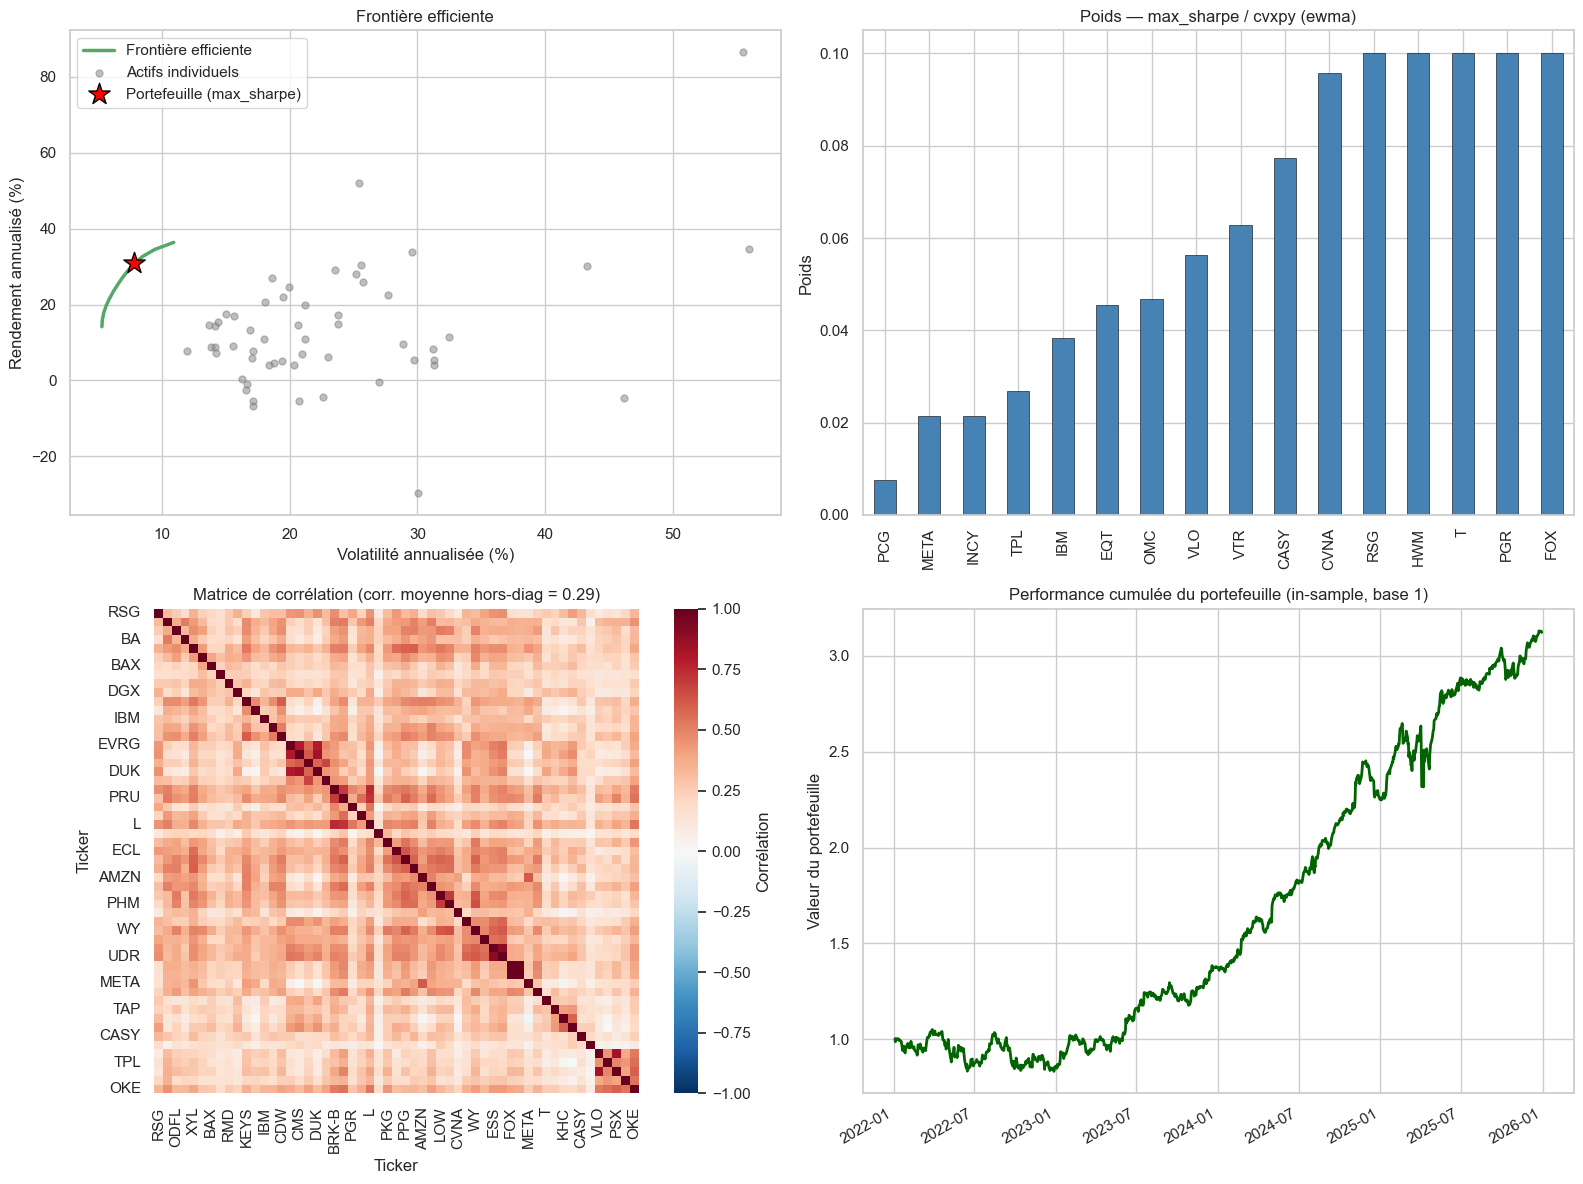

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plot_efficient_frontier(result, ax=axes[0, 0])
plot_weights(result, ax=axes[0, 1])
plot_correlation(result, ax=axes[1, 0])
plot_performance(result, ax=axes[1, 1])
plt.tight_layout(); plt.show()

## 11. Comparaison des estimateurs de covariance (exigence #9)

On garde **tout fixe** (univers, fréquence, objectif, optimiseur) et on ne fait varier **que l'estimateur de Σ**.
On compare le portefeuille obtenu et ses métriques de risque. C'est la traduction directe de l'analyse RiskMetrics :
*est-ce que repondérer les observations change le portefeuille et sa stabilité ?*

In [17]:
from dataclasses import replace

estimators = [
    EmpiricalCovariance(),
    RollingCovariance(window=120),
    EWMACovariance(lam=0.94),
    EWMACovariance(lam=0.97),
    LedoitWolfCovariance(),
]

rows, results_by_est = [], {}
for est in estimators:
    cfg = replace(base_config, cov_estimator=est)
    res = run_experiment(cfg, constituents=constituents, prices=prices)
    results_by_est[est.name + (f"(λ={est.lam})" if isinstance(est, EWMACovariance) else "")] = res
    # conditionnement de la matrice annualisée (diagnostic de stabilité numérique)
    ev = np.linalg.eigvalsh(res.Sigma_annual.values)
    cond = ev.max() / max(ev.min(), 1e-12)
    rows.append({
        "estimateur": est.name + (f" λ={est.lam}" if isinstance(est, EWMACovariance) else ""),
        "rendement (%)": res.ret * 100, "volatilité (%)": res.vol * 100, "Sharpe": res.sharpe,
        "Herfindahl": float((res.weights ** 2).sum()),
        "# poids >1%": int((res.weights > 0.01).sum()),
        "conditionnement Σ": cond,
    })

comparison = pd.DataFrame(rows).set_index("estimateur")
print("Comparaison des estimateurs (univers/objectif/optimiseur identiques) :\n")
comparison.round(3)

Comparaison des estimateurs (univers/objectif/optimiseur identiques) :



,rendement (%),volatilité (%),Sharpe,Herfindahl,# poids >1%,conditionnement Σ
estimateur,,,,,,
empirique,29.2420,16.7350,1.5080,0.0890,13,2845.9010
rolling,30.0440,8.6160,3.0230,0.0760,16,1473.2590
ewma λ=0.94,30.8090,7.8460,3.4170,0.0800,15,3677.8150
ewma λ=0.97,30.9670,9.3290,2.8910,0.0810,16,1376.3060
ledoit-wolf,29.2960,16.6600,1.5180,0.0880,13,707.0220


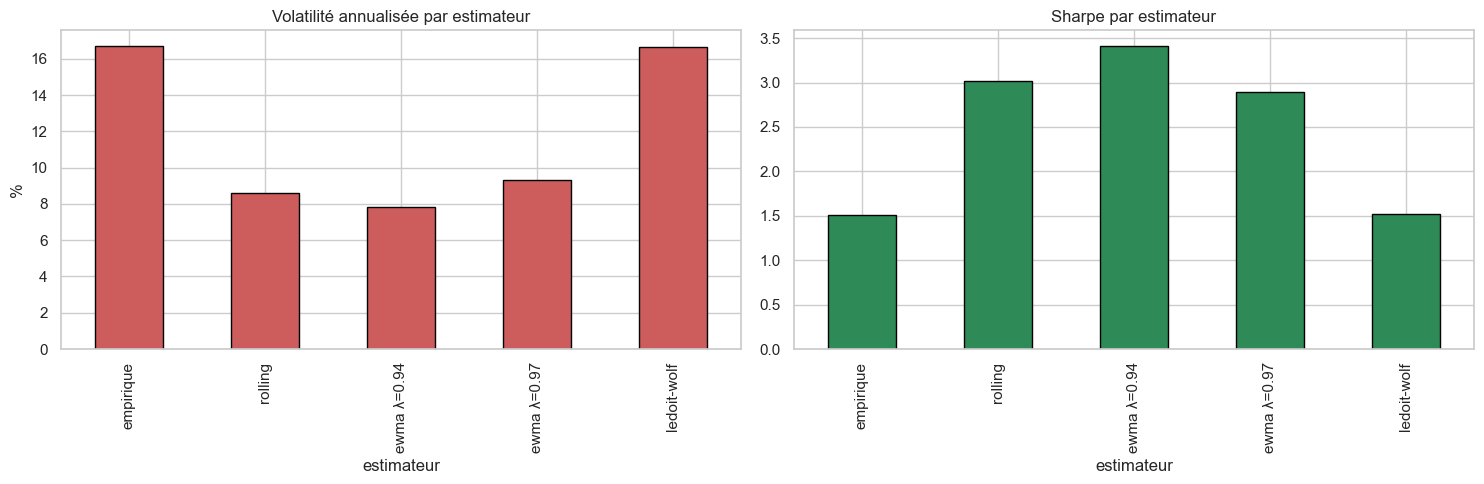

In [18]:
# Visualisation : volatilité et Sharpe par estimateur
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comparison["volatilité (%)"].plot(kind="bar", ax=axes[0], color="indianred", edgecolor="black")
axes[0].set_title("Volatilité annualisée par estimateur"); axes[0].set_ylabel("%")
comparison["Sharpe"].plot(kind="bar", ax=axes[1], color="seagreen", edgecolor="black")
axes[1].set_title("Sharpe par estimateur")
plt.tight_layout(); plt.show()

In [19]:
# Stabilité des poids : à quel point les portefeuilles diffèrent-ils selon l'estimateur ?
W = pd.DataFrame({name: res.weights for name, res in results_by_est.items()}).fillna(0)
print("Écart maximal de poids entre estimateurs, par actif (top 10) :")
print((W.max(axis=1) - W.min(axis=1)).sort_values(ascending=False).head(10).round(4).to_string())

Écart maximal de poids entre estimateurs, par actif (top 10) :
FOX    0.1000
VTR    0.1000
STX    0.0829
DUK    0.0748
FOXA   0.0721
IBM    0.0708
CVNA   0.0697
OMC    0.0468
VLO    0.0464
TPL    0.0457


## 12. Mini-benchmark : balayer plusieurs configurations

Puisque tout passe par `ExperimentConfig` + `run_experiment`, comparer des objectifs, des fréquences ou des
optimiseurs tient en quelques lignes. Exemple : comparer les quatre fonctions objectif.

In [20]:
bench_rows = []
for obj in ["min_variance", "max_sharpe", "max_return", "max_utility"]:
    cfg = replace(base_config, objective=obj)
    res = run_experiment(cfg, constituents=constituents, prices=prices)
    bench_rows.append(res.summary())
benchmark = pd.DataFrame(bench_rows).set_index("objectif")
benchmark[["rendement (%)", "volatilité (%)", "Sharpe", "# poids > 1%", "Herfindahl"]].round(3)

,rendement (%),volatilité (%),Sharpe,# poids > 1%,Herfindahl
objectif,,,,,
min_variance,14.1400,5.3050,1.9110,18,0.0740
max_sharpe,30.8090,7.8460,3.4170,15,0.0800
max_return,37.7440,14.6860,2.2980,10,0.1000
max_utility,37.2490,12.4830,2.6640,11,0.0950


## 13. Architecture, synthèse et pistes

### Architecture du framework

```
ExperimentConfig ───────────────► run_experiment() ──────────► ExperimentResult
  ├─ UniverseSelector             │  1. sélection univers          ├─ weights
  │   {All, TopN, RandomN,        │  2. download + clean prix       ├─ ret / vol / sharpe
  │    StratifiedBySector}        │  3. resample (fréquence)        ├─ μ, Σ (annualisés)
  ├─ frequency / return_mode      │  4. compute_returns             └─ summary()
  ├─ MeanEstimator {SampleMean}   │  5. μ = MeanEstimator
  ├─ CovarianceEstimator          │  6. Σ = CovarianceEstimator        Visualisations :
  │   {Empirical, Rolling,        │  7. annualize                      plot_efficient_frontier
  │    EWMA, LedoitWolf}          │  8. Optimizer.solve(objective)     plot_weights / plot_correlation
  └─ Optimizer                    │                                    plot_performance
      {Lagrangian, CVXPY,         │
       Scipy, DiffEvolution}      │
```

Les quatre familles (`UniverseSelector`, `CovarianceEstimator`, `MeanEstimator`, `Optimizer`) suivent le
**patron Strategy** : chacune est une `ABC` avec une méthode unique. **Étendre = ajouter une classe**, sans
toucher au reste — c'est ce qui rend le notebook benchmarkable.

### Dépendances
`numpy`, `pandas`, `matplotlib`, `seaborn`, `scipy` (toujours) · `cvxpy` (QP) · `yfinance` (données) ·
`scikit-learn` (Ledoit-Wolf, optionnel).

### À retenir
- L'**EWMA** rafraîchit la mesure de risque et tend à donner des portefeuilles plus stables dans le temps,
  pour un coût de calcul négligeable et une matrice PSD garantie.
- Le gain est surtout net sur **min_variance** (qui ne dépend que de Σ) ; sur **max_sharpe**, l'instabilité
  due à μ reste dominante — d'où l'intérêt des contraintes (`long_only`, `w_max`) et, plus tard, d'un travail
  sur μ.

### Pistes (prochaine itération)
1. **Backtest glissant** hors échantillon (rolling window + ré-optimisation) avec **tracking error** et coûts de transaction.
2. **Travail sur μ** : Black-Litterman, estimateurs de James-Stein.
3. **Σ EWMA + shrinkage** combinés (réactivité *et* bon conditionnement pour l'univers complet).
4. **Taux sans risque dynamique** : série T-bill via FRED/yfinance à chaque date du backtest.
5. **Ajouter des métriques de risque avancées** : Maximum drawdown, ratio de Sortino, VaR et CVaR (Value at Risk / Conditional Value at Risk).
6. **Ajouter un backtest walk-forward** : À chaque date de rebalancement, ré-estimer $\hat{\mu}$ et $\hat{\Sigma}$ sur une fenêtre glissante, optimiser le portefeuille, puis mesurer la performance sur la période suivante. C'est la brique la plus importante pour passer d'un exercice pédagogique à un outil de recherche.
7. **Ajouter des contraintes sectorielles :** Permettre de limiter l'exposition à un secteur GICS dans le CVXPYOptimizer
8. **Activer demean=True par défaut dans EWMACovariance**
9. **Taux sans risque dynamique**
10. **Ajouter un benchmark**: Comparer la performance du portefeuille optimisé à un benchmark equal-weight (1/N) ou au SPY.
11. **Ajouter des tests unitaires **: Vérifier que les optimiseurs retournent des poids qui somment à 1, que les contraintes long-only sont respectées, etc.




## 14. Walk-forward out-of-sample backtesting

This section now reuses the reusable module in backtest.py instead of redefining helper classes/functions in the notebook.

In [24]:
from importlib import reload
import backtest as bt

# Optional while iterating: reload the module so notebook picks up file edits immediately.
bt = reload(bt)

WalkForwardBacktestConfig = bt.WalkForwardBacktestConfig
walk_forward_backtest = bt.walk_forward_backtest
plot_backtest_nav = bt.plot_backtest_nav

In [25]:
backtest_cfg = WalkForwardBacktestConfig(
    estimation_window=252,
    holding_period=21,
    transaction_cost_bps=10,
    long_only=base_config.long_only,
    frequency=base_config.frequency,
 )

def make_optimize_fn(cfg):
    def optimize_weights_fn(train_returns: pd.DataFrame):
        mu_period = cfg.mean_estimator.estimate(train_returns)
        sigma_period = cfg.cov_estimator.estimate(train_returns)
        mu, sigma = annualize(mu_period, sigma_period.values, cfg.frequency)
        weights = cfg.optimizer.solve(
            mu,
            sigma,
            objective=cfg.objective,
            rf=cfg.risk_free_annual,
            long_only=cfg.long_only,
            w_max=cfg.w_max,
            risk_aversion=cfg.risk_aversion,
        )
        return np.asarray(weights).flatten()
    return optimize_weights_fn

estimator_backtests = {}
for est in estimators:
    cfg = replace(base_config, cov_estimator=est)
    label = est.name + (f" (lam={est.lam})" if isinstance(est, EWMACovariance) else "")
    estimator_backtests[label] = walk_forward_backtest(
        prices=prices,
        optimize_weights_fn=make_optimize_fn(cfg),
        backtest_config=backtest_cfg,
        compute_returns_fn=lambda px, mode=cfg.return_mode: compute_returns(px, mode),
        label=label,
    )

estimator_backtest_summary = pd.DataFrame(
    {name: result.metrics for name, result in estimator_backtests.items()}
).T.sort_values("Sharpe", ascending=False)

estimator_backtest_summary.round(3)

,Total return (%),CAGR (%),Vol annualized (%),Sharpe,Max drawdown (%),Benchmark total return (%),Benchmark CAGR (%),Benchmark vol annualized (%),Tracking error (%),Average turnover,Rebalance count
ledoit-wolf,87.9230,23.6460,14.6100,1.6180,-15.5230,71.9410,20.0030,14.0040,9.0330,0.0230,36.0000
empirique,86.3790,23.3030,14.4840,1.6090,-15.5480,71.9410,20.0030,14.0040,9.0410,0.0230,36.0000
ewma (lam=0.97),82.9410,22.5330,14.6930,1.5340,-16.4150,71.9410,20.0030,14.0040,9.3320,0.0280,36.0000
rolling,78.7070,21.5720,14.6370,1.4740,-14.9260,71.9410,20.0030,14.0040,9.1470,0.0260,36.0000
ewma (lam=0.94),66.9160,18.8120,14.7840,1.2720,-16.9020,71.9410,20.0030,14.0040,9.1960,0.0370,36.0000


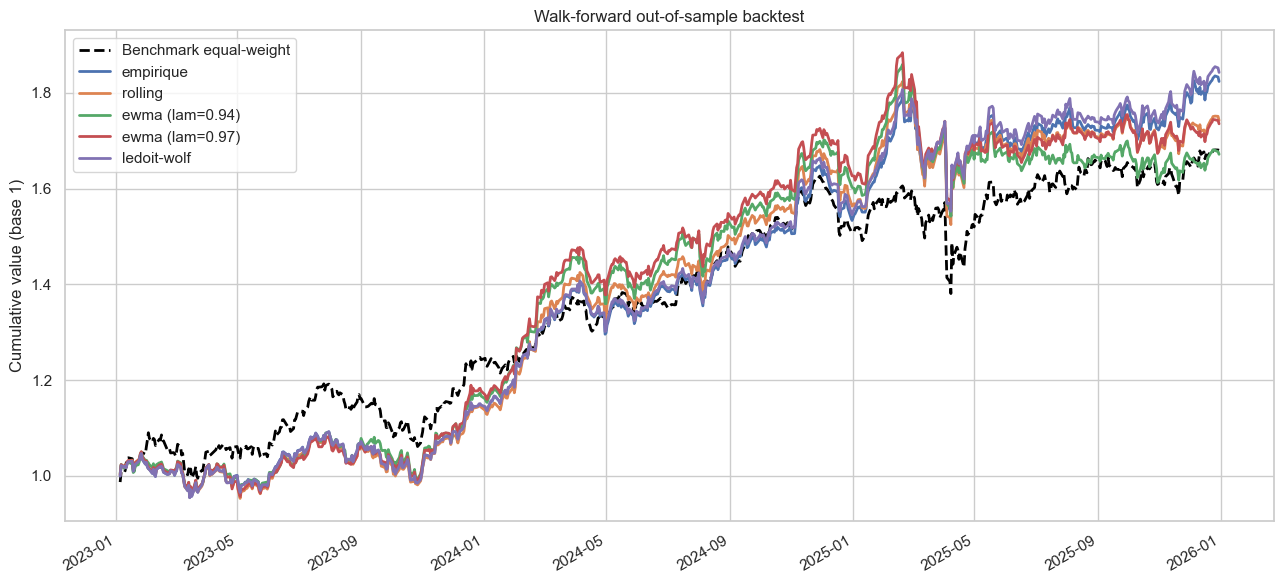

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_backtest_nav(estimator_backtests, ax=ax)
plt.tight_layout()
plt.show()

In [26]:
# Example 2: backtest objective functions (reusing backtest.py)
objective_backtests = {}
for objective in ["min_variance", "max_sharpe", "max_return", "max_utility"]:
    cfg = replace(base_config, objective=objective, cov_estimator=EWMACovariance(lam=0.94))
    objective_backtests[objective] = walk_forward_backtest(
        prices=prices,
        optimize_weights_fn=make_optimize_fn(cfg),
        backtest_config=backtest_cfg,
        compute_returns_fn=lambda px, mode=cfg.return_mode: compute_returns(px, mode),
        label=objective,
    )

objective_backtest_summary = pd.DataFrame(
    {name: result.metrics for name, result in objective_backtests.items()}
).T.sort_values("Sharpe", ascending=False)

objective_backtest_summary.round(3)

,Total return (%),CAGR (%),Vol annualized (%),Sharpe,Max drawdown (%),Benchmark total return (%),Benchmark CAGR (%),Benchmark vol annualized (%),Tracking error (%),Average turnover,Rebalance count
max_return,169.9100,39.6630,20.4490,1.9400,-18.4420,71.9410,20.0030,14.0040,13.0620,0.0230,36.0000
max_utility,137.6150,33.8020,19.2540,1.7560,-17.3180,71.9410,20.0030,14.0040,12.2440,0.0260,36.0000
max_sharpe,66.9160,18.8120,14.7840,1.2720,-16.9020,71.9410,20.0030,14.0040,9.1960,0.0370,36.0000
min_variance,21.3600,6.7300,12.2930,0.5470,-13.9920,71.9410,20.0030,14.0040,8.0030,0.0470,36.0000


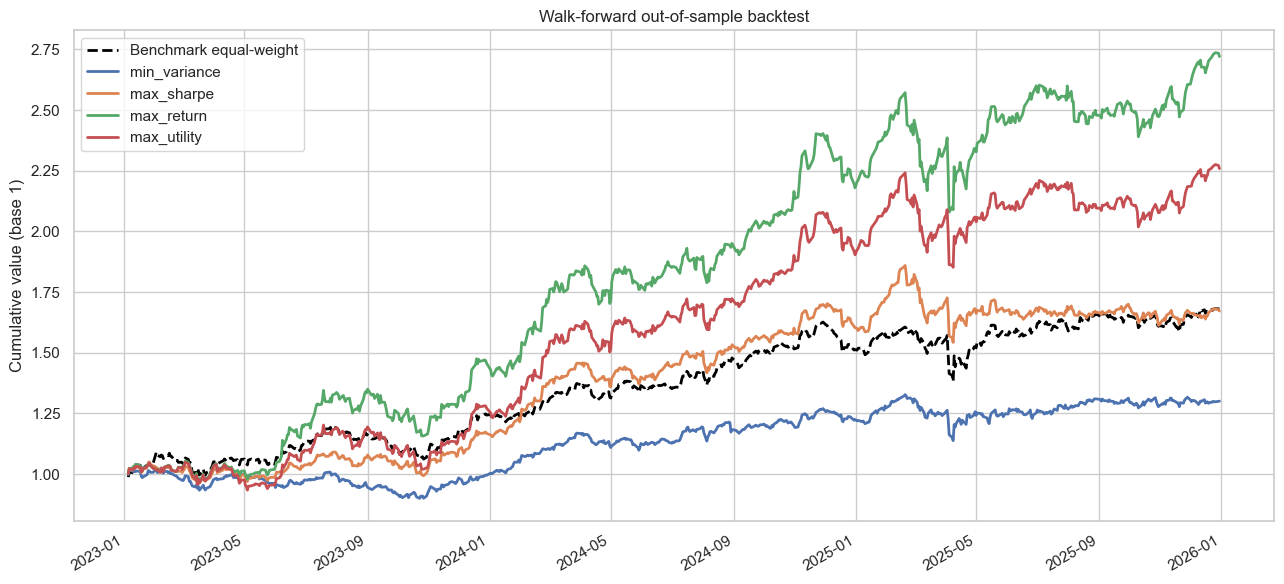

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_backtest_nav(objective_backtests, ax=ax)
plt.tight_layout()
plt.show()